# 05 - Advanced Analytics

## Bluestock Mutual Fund Capstone

### Objectives

- Value at Risk (VaR)
- Cohort Analysis
- Mutual Fund Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

In [3]:
nav.head()
transactions.head()
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [4]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

In [5]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

## Value at Risk (VaR)

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

In [8]:
nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [9]:
var_table = nav.groupby(
    "amfi_code"
)["daily_return"].quantile(0.05)

var_table = var_table.reset_index()

var_table.columns = [
    "amfi_code",
    "VaR_95"
]

var_table.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [10]:
var_table.to_csv(
    "../reports/value_at_risk.csv",
    index=False
)

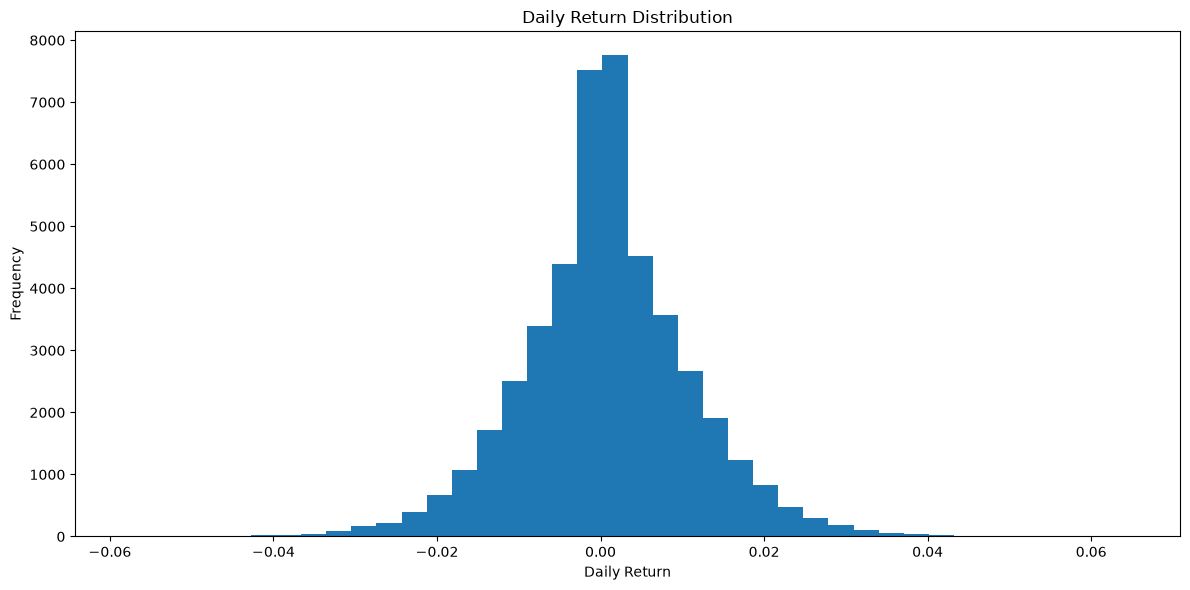

In [11]:
plt.figure(figsize=(12,6))

plt.hist(
    nav["daily_return"].dropna(),
    bins=40
)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../reports/value_at_risk.png")

plt.show()

## Cohort Analysis

In [12]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [13]:
transactions["Month"] = transactions[
    "transaction_date"
].dt.to_period("M")

In [14]:
cohort = transactions.groupby(

["Month","transaction_type"]

)["amount_inr"].sum().reset_index()

cohort.head()

,Month,transaction_type,amount_inr
0,2024-01,Lumpsum,125509831
1,2024-01,Redemption,79503125
2,2024-01,SIP,12635349
3,2024-02,Lumpsum,111404051
4,2024-02,Redemption,69871989


In [15]:
pivot = cohort.pivot(

index="Month",

columns="transaction_type",

values="amount_inr"

).fillna(0)

pivot

transaction_type,Lumpsum,Redemption,SIP
Month,,,
2024-01,125509831,79503125,12635349
2024-02,111404051,69871989,12613376
2024-03,124810113,76554972,12088413
2024-04,127545599,67445890,13512385
2024-05,114669898,77237848,13218606
2024-06,124985567,84148612,13131150
2024-07,117142475,67075667,13513884
2024-08,134046496,81237196,12521433
2024-09,113775104,62497934,12288778


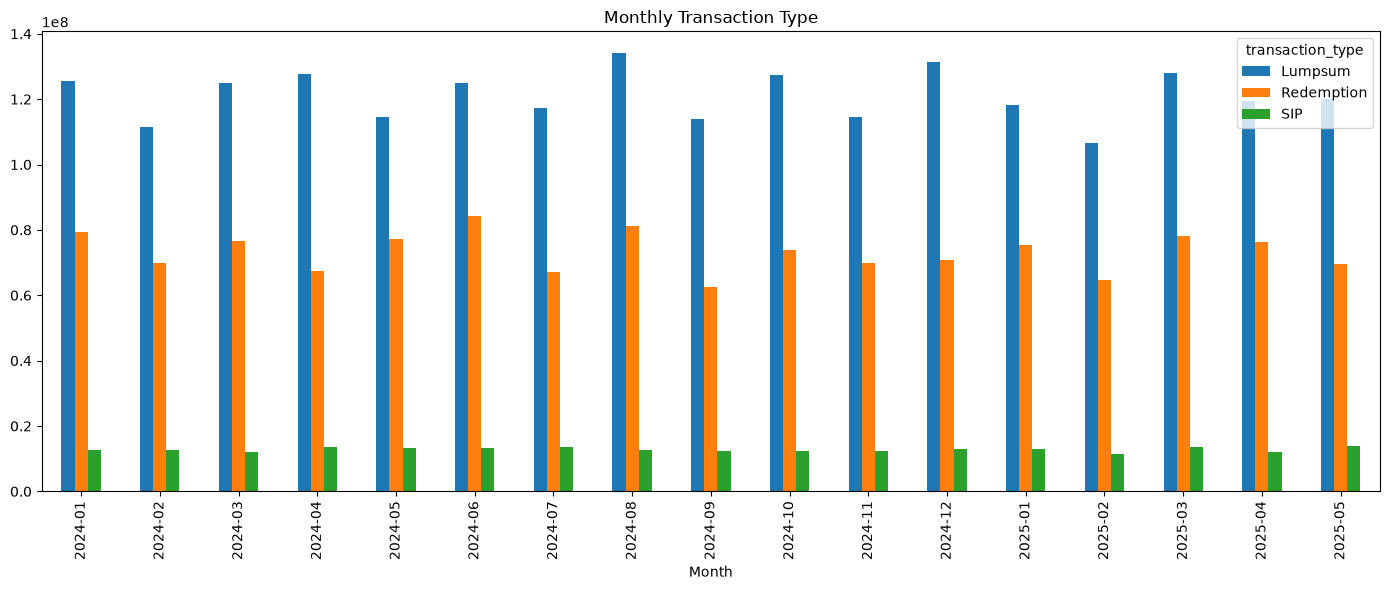

In [16]:
pivot.plot(

kind="bar",

figsize=(14,6)

)

plt.title("Monthly Transaction Type")

plt.tight_layout()

plt.savefig("../reports/cohort_analysis.png")

plt.show()

## Mutual Fund Recommendation

In [17]:
recommend = performance[
[
"scheme_name",

"category",

"return_3yr_pct",

"sharpe_ratio",

"expense_ratio_pct"

]
]

In [18]:
recommend["Score"]=(

recommend["return_3yr_pct"]*0.5+

recommend["sharpe_ratio"]*25-

recommend["expense_ratio_pct"]*5

)

In [19]:
recommend = recommend.sort_values(

"Score",

ascending=False

)

recommend.head(10)

,scheme_name,category,return_3yr_pct,sharpe_ratio,expense_ratio_pct,Score
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,0.74,192.140
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,0.60,154.590
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,0.79,127.120
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,7.37,1.84,0.56,46.885
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,0.77,37.185
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33,0.55,33.155
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,23.14,0.93,0.72,31.220
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,14.41,1.03,0.80,28.955
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,23.39,0.94,1.43,28.045
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,14.81,1.06,1.46,26.605


In [20]:
recommend.to_csv(

"../reports/recommended_funds.csv",

index=False

)

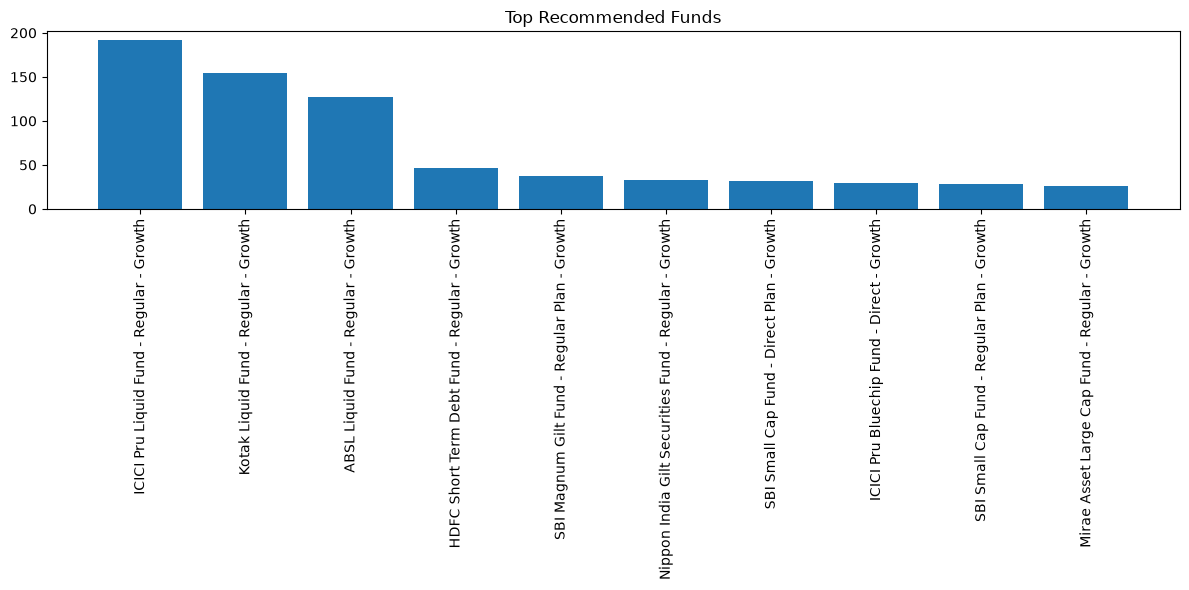

In [21]:
plt.figure(figsize=(12,6))

plt.bar(

recommend.head(10)["scheme_name"],

recommend.head(10)["Score"]

)

plt.xticks(rotation=90)

plt.title("Top Recommended Funds")

plt.tight_layout()

plt.savefig("../reports/recommended_funds.png")

plt.show()

## State-wise Investment Analysis

In [22]:
state = transactions.groupby(

"state"

)["amount_inr"].sum().sort_values(

ascending=False

)

state.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

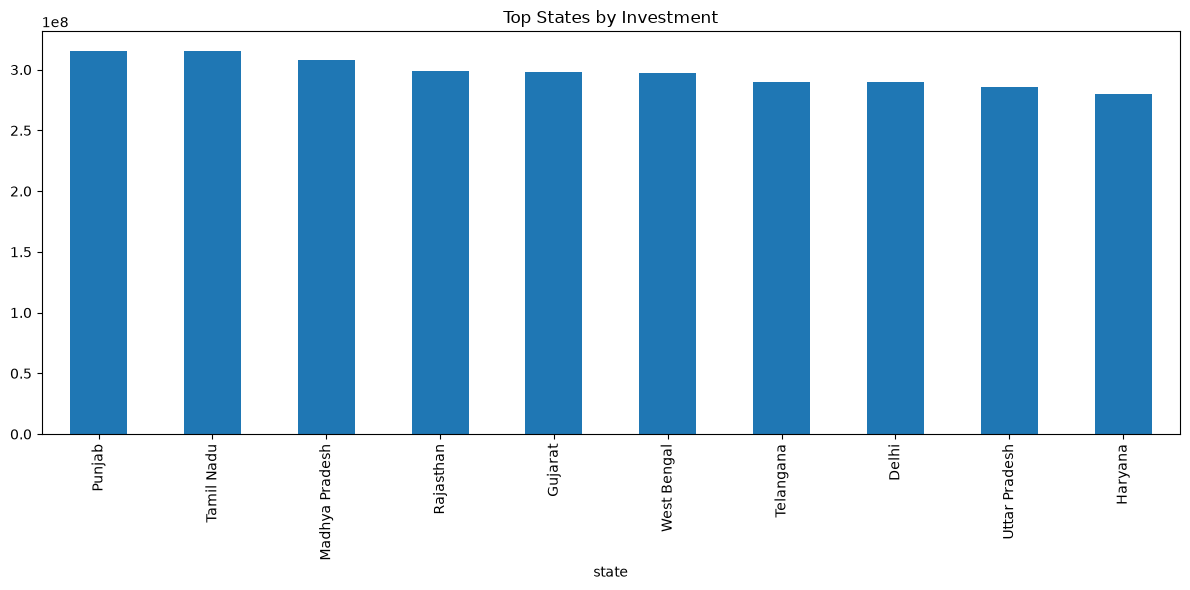

In [23]:
plt.figure(figsize=(12,6))

state.head(10).plot(

kind="bar"

)

plt.title("Top States by Investment")

plt.tight_layout()

plt.savefig("../reports/state_analysis.png")

plt.show()

## Annual Income Analysis

In [24]:
income = transactions.groupby(

"annual_income_lakh"

)["amount_inr"].mean()

income

annual_income_lakh
3.0     105786.448276
3.1     108559.198473
3.2     117743.542857
3.3     110498.591837
3.4     135781.581395
            ...      
98.7     99090.250000
99.0      3770.000000
99.2    385272.000000
99.3    123857.333333
99.7    143167.166667
Name: amount_inr, Length: 804, dtype: float64

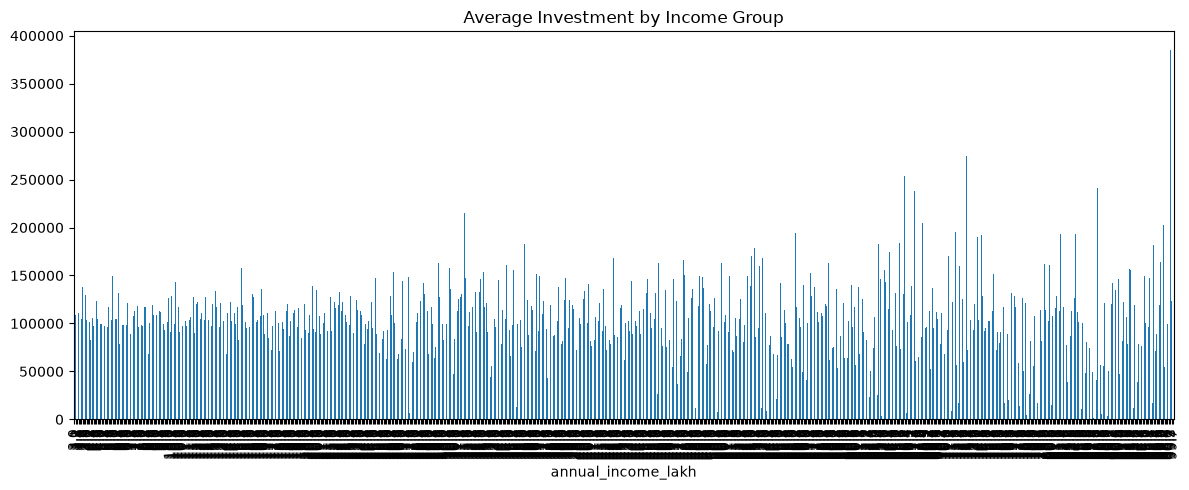

In [25]:
income.plot(

kind="bar",

figsize=(12,5)

)

plt.title("Average Investment by Income Group")

plt.tight_layout()

plt.savefig("../reports/income_analysis.png")

plt.show()

# Conclusion

### Key Findings

- Calculated Value at Risk (VaR) using historical daily returns.
- Analyzed monthly investment behaviour across transaction types.
- Built a simple mutual fund recommendation model based on return, Sharpe Ratio, and expense ratio.
- Identified top investing states.
- Compared average investment amount across income groups.

This notebook demonstrates advanced analytics techniques useful for mutual fund investment analysis and supports informed investment decisions.